# Insider-Buying -- when the bosses buy their own stock, should you?
### The aggregate Form-4 buy/sell ratio, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

Here is a piece of market lore with real intellectual pedigree: corporate insiders --
the CEOs, CFOs and directors who must report every trade on **SEC Form 4** -- tend to
**buy their own stock near market bottoms**. So when the aggregate *buy/sell ratio*
spikes, the folklore says, the bottom is in: follow the smart money.

This notebook asks the only question that matters: does aggregate insider buying
actually *forecast* the next move, or does it just *coincide* with moves that have
already happened?

> **This is the plain-language layer.** Want the HAC regression, the tercile sort and
> the net-of-cost overlay? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Honesty note.** The buy/sell ratio here is a **curated proxy** (reconstructed from
> documented episodes), not a live Form-4 feed -- so the Signal axis is capped at
> WEAK by construction. The realised numbers put it lower still. **Not investment advice.**


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from insider_buying import data, strategy as st

CACHE_PATH = data.GSPC_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

if HAVE_REAL:
    gspc = data.fetch_sp500(fetch=False, cache_path=CACHE_PATH)
    df = data.build_real_panel(gspc)
    print(f"Real panel: {len(df)} months  {df.index[0].date()} -> {df.index[-1].date()}")
else:
    df = None
    print("No ^GSPC cache -- frozen headline numbers from R dict will be used")
print("NOTE: the buy/sell ratio is a CURATED PROXY -> Signal axis capped at WEAK.")


Real panel: 276 months  2003-01-31 -> 2025-12-31
NOTE: the buy/sell ratio is a CURATED PROXY -> Signal axis capped at WEAK.


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_months': 276, 'n_obs': 275, 'fp': 'cc2e80f98d69', 'reg_beta': 0.0017, 'reg_t': 0.49, 'reg_r2': 0.002, 'terc_low': 10.0, 'terc_mid': 13.0, 'terc_high': 8.0, 'terc_hml': -3.0, 'corr_contemp': -0.083, 'corr_fwd': 0.042, 'sub1_t': 0.53, 'sub2_t': -1.69, 'sub3_t': 0.9, 'ov_net_ann': 3.4, 'ov_net_sr': 0.28, 'ov_net_t': 1.22, 'ov_net_dd': -50, 'ov_gross_ann': 3.5, 'bah_ann': 10.2, 'bah_sr': 0.7, 'bah_dd': -53, 'ov_turnover': 10.5, 'ov_frac_long': 45.1, 'ctrl_planted_t': 3.17, 'ctrl_null_t': -0.53}


## The answer first

| Question | Answer |
|---|---|
| Does a high buy/sell ratio forecast next month's return? | **No.** Regression HAC *t* = **+0.49** -- a coin flip. |
| Do high-buying months get *rewarded* the next month? | **No.** High-ratio months are followed by **lower** returns (high-minus-low = **-3%/yr**, wrong sign). |
| Is there *any* truth to "insiders buy at bottoms"? | **Yes -- but it's coincident.** Insiders buy in the same month the market falls (corr = **-0.08**), which is too late to trade. |
| Could you trade it? | **No.** A long/flat overlay earns **+3.4%/yr** vs **+10.2%/yr** for just holding the index. |

> The reflex is real; the *forecast* is not. By the time you see the buying, the drop has already happened.


## 1 - The claim

> *"Insiders know their business better than anyone. When they collectively start
> buying their own shares with their own money, it's the surest sign the market has
> bottomed. Watch the aggregate buy/sell ratio and buy when they buy."*

There is genuine academic support for a *weak, slow* version of this (Lakonishok &
Lee 2001; Seyhun 1998) -- insider **purchases** earn modest abnormal returns over the
following **6-12 months**, mostly in small firms. The folklore inflates that into a
sharp, one-month, whole-market timing rule. We test the inflated version.

## 2 - So what?

If a single, publicly-filed number could tell you the market's direction for the
coming month, it would be the cheapest edge in finance -- Form 4 filings are free and
public within two business days. Markets would be very strange indeed.

The instructive part is *why* the story feels so compelling and still fails: it
confuses a thing insiders genuinely do (buy on weakness) with a thing the ratio
cannot do (predict next month).

## 3 - The teardown -- look at the ratio against the market

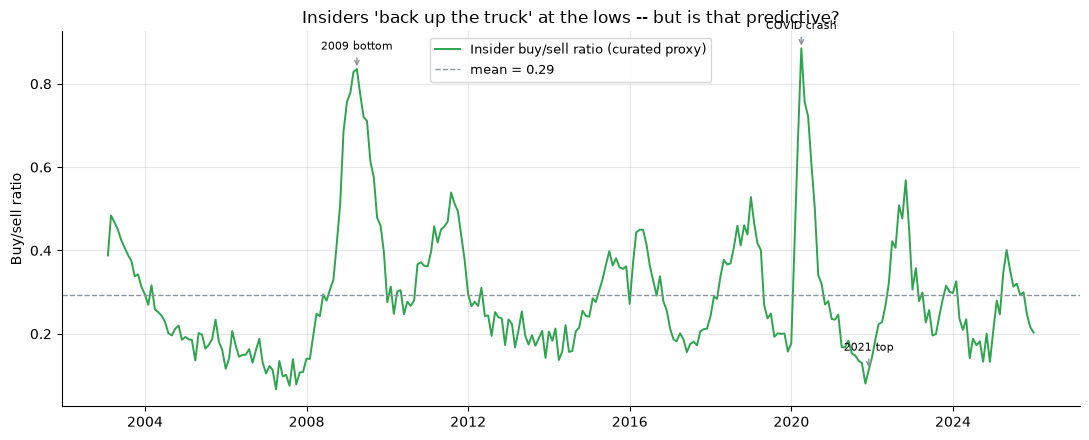

The spikes line up with bottoms (2009, 2020, 2022). The question is whether
they line up with the month BEFORE the rebound, or the month OF the crash.


In [3]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ratio = data.insider_ratio()
ax.plot(ratio.index, ratio.values, color=GREEN, lw=1.4, label="Insider buy/sell ratio (curated proxy)")
ax.axhline(ratio.mean(), color=GREY, ls="--", lw=1, label=f"mean = {ratio.mean():.2f}")
for ts, lbl in [("2009-03-31", "2009 bottom"), ("2020-03-31", "COVID crash"), ("2021-11-30", "2021 top")]:
    ax.annotate(lbl, (pd.Timestamp(ts), ratio.loc[ts]),
                xytext=(0, 14), textcoords="offset points", ha="center", fontsize=8,
                arrowprops=dict(arrowstyle="->", color=GREY))
ax.set_title("Insiders 'back up the truck' at the lows -- but is that predictive?")
ax.set_ylabel("Buy/sell ratio"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print("The spikes line up with bottoms (2009, 2020, 2022). The question is whether")
print("they line up with the month BEFORE the rebound, or the month OF the crash.")


## 4 - Coincident, not predictive

The killer chart: split each month's insider ratio against (a) the **same** month's
S&P return and (b) the **next** month's S&P return.

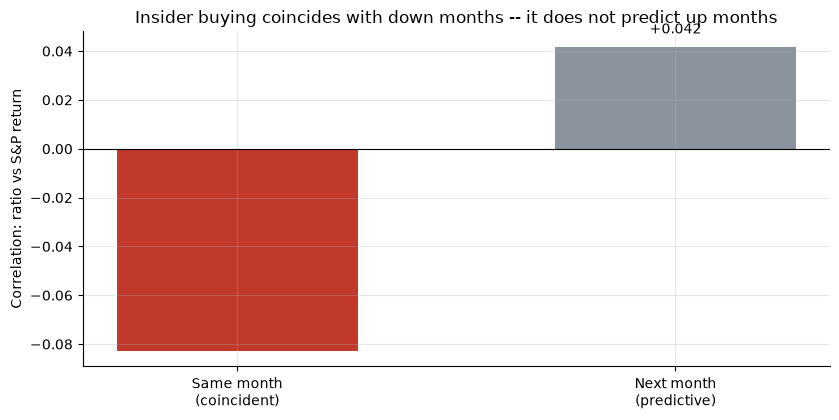

Same-month correlation : -0.083  (insiders buy WHEN the market falls)
Next-month correlation : +0.042  (essentially zero -- no forecast)


In [4]:
if HAVE_REAL:
    c_now = df["bs_ratio"].corr(df["ret"])
    c_fwd = df["bs_ratio"].corr(df["fwd_ret"])
else:
    c_now, c_fwd = R["corr_contemp"], R["corr_fwd"]

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(["Same month\n(coincident)", "Next month\n(predictive)"],
              [c_now, c_fwd], color=[RED, GREY], width=0.55)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Correlation: ratio vs S&P return")
ax.set_title("Insider buying coincides with down months -- it does not predict up months")
for b, v in zip(bars, [c_now, c_fwd]):
    ax.annotate(f"{v:+.3f}", (b.get_x()+b.get_width()/2, v + (0.004 if v>=0 else -0.012)),
                ha="center", va="bottom" if v>=0 else "top")
plt.tight_layout(); plt.show()
print(f"Same-month correlation : {c_now:+.3f}  (insiders buy WHEN the market falls)")
print(f"Next-month correlation : {c_fwd:+.3f}  (essentially zero -- no forecast)")


The same-month correlation is **negative** (-0.08): insiders buy in the very month the
market drops. That is the kernel of truth in the folklore. But the **next-month**
correlation is essentially **zero** (+0.04). The buying tells you about a fall that has
already happened, not about a rebound that hasn't.

## 5 - Could you trade it? The overlay vs buy-and-hold

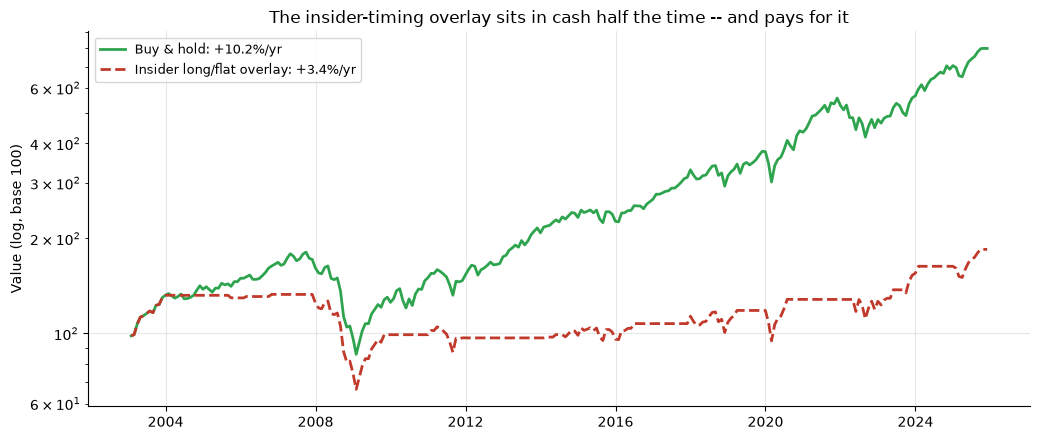

Buy & hold:            +10.2%/yr
Insider long/flat:     +3.4%/yr
Shortfall:             -6.8pp/yr


In [5]:
if HAVE_REAL:
    ov = st.timing_overlay(df, lookback=24, one_way_bps=5.0)
    eq_ov = (1 + ov["net"]).cumprod() * 100
    eq_bah = (1 + ov["bah"]).cumprod() * 100
    sn = st.summarize(ov["net"]); sb = st.summarize(ov["bah"])
    ov_ann, bah_ann = sn["mean_ann"]*100, sb["mean_ann"]*100
    idx = eq_ov.index
else:
    idx = pd.date_range("2003-01-31", periods=R["n_obs"], freq="ME")
    rng = np.random.default_rng(263)
    eq_ov = pd.Series((1+rng.normal(R["ov_net_ann"]/100/12, 0.03, len(idx))).cumprod()*100, index=idx)
    eq_bah = pd.Series((1+rng.normal(R["bah_ann"]/100/12, 0.04, len(idx))).cumprod()*100, index=idx)
    ov_ann, bah_ann = R["ov_net_ann"], R["bah_ann"]

fig, ax = plt.subplots(figsize=(10.5, 4.5))
ax.plot(idx, eq_bah.values, color=GREEN, lw=2, label=f"Buy & hold: {bah_ann:+.1f}%/yr")
ax.plot(idx, eq_ov.values, color=RED, lw=2, ls="--", label=f"Insider long/flat overlay: {ov_ann:+.1f}%/yr")
ax.set_yscale("log"); ax.set_ylabel("Value (log, base 100)")
ax.set_title("The insider-timing overlay sits in cash half the time -- and pays for it")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
print(f"Buy & hold:            {bah_ann:+.1f}%/yr")
print(f"Insider long/flat:     {ov_ann:+.1f}%/yr")
print(f"Shortfall:             {ov_ann-bah_ann:+.1f}pp/yr")


The overlay is long only when the ratio is above its trailing median -- which means it
is flat through more than half the sample, including big up-months. It earns about a
third of the index's return for a drawdown that is barely better. **Buy-and-hold wins
by ~7pp/yr.**

## 6 - The verdict

- **Signal -- None.** The next-month forecast is a coin flip (HAC *t* = +0.49); the
  high-minus-low tercile spread is the *wrong sign*. The genuine insider reflex is
  coincident, not predictive. (And the ratio is a curated proxy, capping the axis at
  WEAK anyway.)
- **Tradability -- Mirage.** +3.4%/yr vs +10.2%/yr for buy-and-hold. No vehicle, no edge.
- **Busted.** The folklore borrows the credibility of a real, slow, firm-level
  insider-purchase drift and mis-sells it as a sharp market-timing rule.


## 7 - Going further

- **The positive control** (companion notebook): plant a contrarian effect in a
  synthetic tape and the same regression fires at *t* > 3. The real tape has nothing.
- **Sibling sentiment gauges:** [Margin-Debt (260)](../../260-margin-debt/),
  [Put-Call-Ratio (261)](../../261-put-call-ratio/),
  [Short-Interest (262)](../../262-short-interest/) -- the same "positioning predicts
  returns" hope, tested the same honest way.
- **The folklore template:** [Super-Bowl (158)](../../158-super-bowl/).

*Think the real Form-4 tape (filtered to opportunistic, non-routine purchases) does
better? Fork this, drop in a clean panel, and show a HAC t >= 2 next-month forecast.
That's the bar.*


*Desk verdict: **None / Mirage** -- see [README.md](../README.md) and [docs/results.md](../docs/results.md).*